# ElasticNet: Vyvážená regulizace pro lineární regresi

## Co je ElasticNet?

ElasticNet je regresní metoda, která kombinuje vlastnosti Lasso (L1 regulizace) a Ridge (L2 regulizace) regrese. Vytváří model, který penalizuje jak absolutní hodnotu koeficientů (L1), tak jejich čtverce (L2). Tato kombinace poskytuje vyváženou regularizaci, která:

1. **Odstraňuje nedůležité proměnné** (díky L1 složce)
2. **Zmenšuje koeficienty silně korelovaných proměnných** (díky L2 složce)
3. **Řeší problém multikolinearity** efektivněji než samostatné metody

### Matematická formulace:

ElasticNet minimalizuje následující funkci:

$$\min_{\beta} \frac{1}{2n} \|y - X\beta\|_2^2 + \alpha \cdot \rho \|\beta\|_1 + \frac{\alpha \cdot (1-\rho)}{2} \|\beta\|_2^2$$

kde:
- $y$ je vektor cílových hodnot
- $X$ jsou vstupní příznaky
- $\beta$ jsou koeficienty modelu
- $\alpha$ je celková síla regulizace
- $\rho$ je poměr mezi L1 a L2 regulizací (L1_ratio)
  - $\rho = 1$: čistá L1 regulizace (Lasso)
  - $\rho = 0$: čistá L2 regulizace (Ridge)
  - $0 < \rho < 1$: kombinace obou regulizací (ElasticNet)

### Kdy použít ElasticNet:

1. Když řešíte problém s multikolinearitou
2. Když chcete výběr příznaků i stabilitu koeficientů zároveň
3. Když počet příznaků je větší než počet vzorků
4. Při úlohách, kde je důležitá interpretace modelu

Pojďme si ElasticNet podrobně prozkoumat v praxi!

In [1]:
# Import potřebných knihoven
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from time import time
from sklearn.linear_model import ElasticNet, Lasso, Ridge, LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.datasets import fetch_california_housing, load_diabetes, make_regression
from sklearn.pipeline import Pipeline

# Nastavení vizualizací
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
sns.set(font_scale=1.2)

# Pro reprodukovatelnost
np.random.seed(42)

## 1. Porovnání ElasticNet, Ridge a Lasso regrese

Nejprve porovnejme, jak se ElasticNet liší od svých "rodičů" - Ridge a Lasso regrese. Vytvoříme syntetický dataset se silně korelovanými příznaky, kde očekáváme, že ElasticNet bude mít výhody oproti oběma metodám.

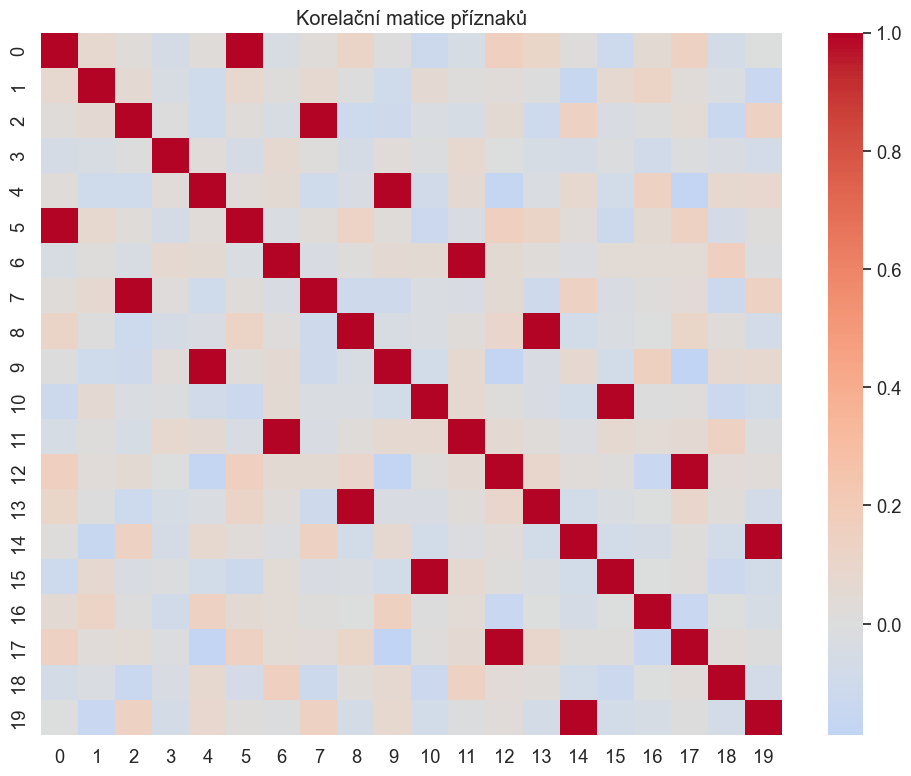

Tvar datasetu: (200, 20)
Počet trénovacích vzorků: 160
Počet testovacích vzorků: 40


In [2]:
# Vytvoření syntetického datasetu se silně korelovanými příznaky
def create_correlated_features(n_samples=200, n_features=20, n_informative=5, noise=0.5, random_state=42):
    """Vytvoří dataset se silně korelovanými příznaky"""
    X, y = make_regression(n_samples=n_samples,
                          n_features=n_features,
                          n_informative=n_informative,
                          noise=noise,
                          random_state=random_state)
    
    # Přidání korelace mezi některými příznaky
    rng = np.random.RandomState(random_state)
    for i in range(5, n_features, 2):
        X[:, i] = X[:, i-5] + rng.normal(0, 0.1, n_samples)
    
    # Standardizace příznaků a cílové hodnoty
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    y = (y - y.mean()) / y.std()
    
    return X, y

# Vytvoření datasetu
X, y = create_correlated_features(n_samples=200, n_features=20)

# Rozdělení na trénovací a testovací data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Kontrola korelace mezi příznaky
corr_matrix = np.corrcoef(X.T)

# Vizualizace korelací
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False)
plt.title('Korelační matice příznaků')
plt.tight_layout()
plt.show()

print(f"Tvar datasetu: {X.shape}")
print(f"Počet trénovacích vzorků: {X_train.shape[0]}")
print(f"Počet testovacích vzorků: {X_test.shape[0]}")

In [3]:
# Implementace a porovnání různých regresních modelů
models = {
    'Lineární regrese': LinearRegression(),
    'Ridge regrese (L2)': Ridge(alpha=1.0, random_state=42),
    'Lasso regrese (L1)': Lasso(alpha=0.1, random_state=42),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)
}

# Trénování všech modelů a sběr výsledků
results = {}
coefs = {}

for name, model in models.items():
    # Trénování modelu
    model.fit(X_train, y_train)
    
    # Predikce
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Výpočet metrik
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    # Uložení výsledků
    results[name] = {
        'Train MSE': train_mse,
        'Test MSE': test_mse,
        'Test R²': test_r2
    }
    
    # Uložení koeficientů pro vizualizaci
    if hasattr(model, 'coef_'):
        coefs[name] = model.coef_
    
    print(f"Model: {name}")
    print(f"  Train MSE: {train_mse:.4f}")
    print(f"  Test MSE: {test_mse:.4f}")
    print(f"  Test R²: {test_r2:.4f}")
    
    # Výpis počtu nenulových koeficientů
    if hasattr(model, 'coef_'):
        n_nonzero = np.sum(model.coef_ != 0)
        print(f"  Nenulové koeficienty: {n_nonzero}/{len(model.coef_)}")
    print("")

Model: Lineární regrese
  Train MSE: 0.5404
  Test MSE: 0.7230
  Test R²: 0.2031
  Nenulové koeficienty: 20/20

Model: Ridge regrese (L2)
  Train MSE: 0.5582
  Test MSE: 0.6616
  Test R²: 0.2708
  Nenulové koeficienty: 20/20

Model: Lasso regrese (L1)
  Train MSE: 0.6227
  Test MSE: 0.5904
  Test R²: 0.3493
  Nenulové koeficienty: 4/20

Model: ElasticNet
  Train MSE: 0.6019
  Test MSE: 0.6079
  Test R²: 0.3300
  Nenulové koeficienty: 7/20



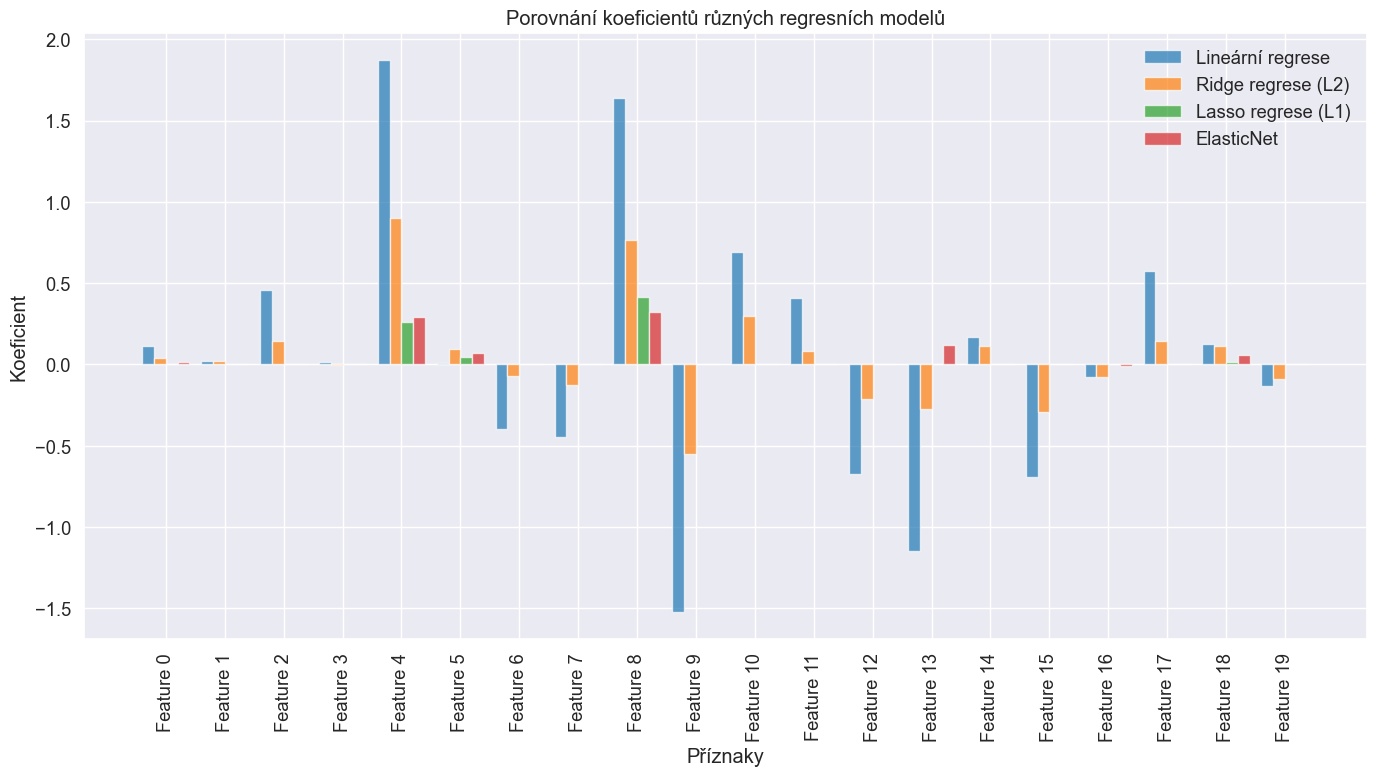

In [4]:
# Vizualizace koeficientů modelů
plt.figure(figsize=(14, 8))

# Příprava dat pro vizualizaci
feature_names = [f"Feature {i}" for i in range(X.shape[1])]
x = np.arange(len(feature_names))
width = 0.2
offsets = [-width*1.5, -width*0.5, width*0.5, width*1.5]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# Vykreslení koeficientů pro každý model
for i, (name, coef) in enumerate(coefs.items()):
    plt.bar(x + offsets[i], coef, width, label=name, color=colors[i], alpha=0.7)

plt.xlabel('Příznaky')
plt.ylabel('Koeficient')
plt.title('Porovnání koeficientů různých regresních modelů')
plt.xticks(x, feature_names, rotation=90)
plt.legend()
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

### Shrnutí rozdílů mezi modely:

- **Lineární regrese**: Nepoužívá regularizaci, což vede k přeučení a nestabilním koeficientům.
- **Ridge regrese (L2)**: Zmenšuje všechny koeficienty, ale žádný není přesně nulový. Dobře řeší multikolinearitu.
- **Lasso regrese (L1)**: Provádí výběr příznaků nastavením některých koeficientů na nulu, ale může být nestabilní při silné korelaci.
- **ElasticNet**: Kombinuje výhody obou přístupů - provádí výběr příznaků a zároveň efektivně řeší multikolinearitu.

## 2. ElasticNet na reálných datech

Nyní aplikujeme ElasticNet na reálný dataset. Použijeme dataset cen nemovitostí v Kalifornii, který obsahuje mnoho potenciálně korelovaných proměnných.

In [5]:
# # Načtení datasetu California Housing
# housing = fetch_california_housing()
# X_housing, y_housing = housing.data, housing.target

# # Základní informace o datasetu
# print("Dataset California Housing:")
# print(f"Tvar datasetu: {X_housing.shape}")
# print(f"Příznaky: {housing.feature_names}")
# print(f"Cíl: {housing.DESCR.split(':\n')[1].split('\n')[0]}\n")

# # Rozdělení dat na trénovací a testovací množinu
# X_train, X_test, y_train, y_test = train_test_split(
#     X_housing, y_housing, test_size=0.2, random_state=42
# )

# # Standardizace dat (důležité pro regularizační modely)
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# # Vytvoření tabulky s popisnými statistikami
# df_housing = pd.DataFrame(X_housing, columns=housing.feature_names)
# df_housing['target'] = y_housing

# print("Popisné statistiky:")
# print(df_housing.describe().round(2))

```
SyntaxError: f-string expression part cannot include a backslash
```

In [6]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Načtení datasetu California Housing
housing = fetch_california_housing()
X_housing, y_housing = housing.data, housing.target

# Základní informace o datasetu
print("Dataset California Housing:")
print(f"Tvar datasetu: {X_housing.shape}")
print(f"Příznaky: {housing.feature_names}")

# Vytažení cílového popisu bezpečně mimo f-string
descr_lines = housing.DESCR.split(':\n')
if len(descr_lines) > 1:
    target_descr = descr_lines[1].split('\n')[0]
    print("Cíl:", target_descr)
else:
    print("Cíl: Popis nebyl nalezen")
print()

# Rozdělení dat na trénovací a testovací množinu
X_train, X_test, y_train, y_test = train_test_split(
    X_housing, y_housing, test_size=0.2, random_state=42
)

# Standardizace dat (důležité pro regularizační modely)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Vytvoření tabulky s popisnými statistikami
df_housing = pd.DataFrame(X_housing, columns=housing.feature_names)
df_housing['target'] = y_housing

print("Popisné statistiky:")
print(df_housing.describe().round(2))

Dataset California Housing:
Tvar datasetu: (20640, 8)
Příznaky: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Cíl: 

Popisné statistiky:
         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
count  20640.00  20640.00  20640.00   20640.00    20640.00  20640.00   
mean       3.87     28.64      5.43       1.10     1425.48      3.07   
std        1.90     12.59      2.47       0.47     1132.46     10.39   
min        0.50      1.00      0.85       0.33        3.00      0.69   
25%        2.56     18.00      4.44       1.01      787.00      2.43   
50%        3.53     29.00      5.23       1.05     1166.00      2.82   
75%        4.74     37.00      6.05       1.10     1725.00      3.28   
max       15.00     52.00    141.91      34.07    35682.00   1243.33   

       Latitude  Longitude    target  
count  20640.00   20640.00  20640.00  
mean      35.63    -119.57      2.07  
std        2.14       2.00      1.15  
min  

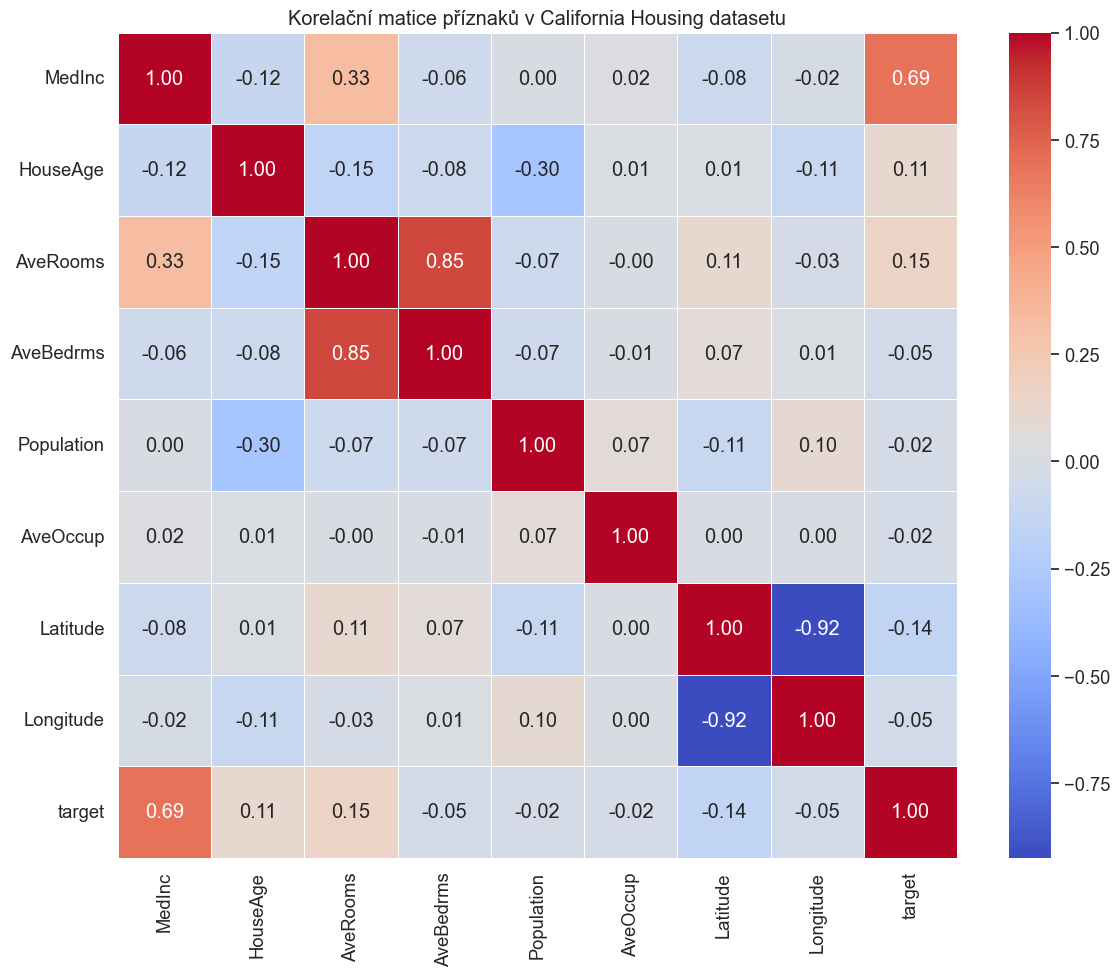

In [7]:
# Vizualizace korelací v datasetu
plt.figure(figsize=(12, 10))
corr_matrix = df_housing.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Korelační matice příznaků v California Housing datasetu')
plt.tight_layout()
plt.show()

In [8]:
# Implementace ElasticNet na California Housing datasetu
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)
elastic.fit(X_train_scaled, y_train)

# Predikce
y_pred_train = elastic.predict(X_train_scaled)
y_pred_test = elastic.predict(X_test_scaled)

# Vyhodnocení modelu
train_mse = mean_squared_error(y_train, y_pred_train)
test_mse = mean_squared_error(y_test, y_pred_test)
test_r2 = r2_score(y_test, y_pred_test)

print("ElasticNet model na California Housing datasetu:")
print(f"  Train MSE: {train_mse:.4f}")
print(f"  Test MSE: {test_mse:.4f}")
print(f"  Test R²: {test_r2:.4f}")

# Zobrazení koeficientů
coef_df = pd.DataFrame({
    'Feature': housing.feature_names,
    'Coefficient': elastic.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

print("\nVýznam příznaků podle ElasticNet:")
print(coef_df.round(4))

ElasticNet model na California Housing datasetu:
  Train MSE: 0.6273
  Test MSE: 0.6359
  Test R²: 0.5148

Význam příznaků podle ElasticNet:
      Feature  Coefficient
0      MedInc       0.7138
6    Latitude      -0.1757
1    HouseAge       0.1373
7   Longitude      -0.1333
3   AveBedrms       0.0000
2    AveRooms      -0.0000
5    AveOccup      -0.0000
4  Population       0.0000


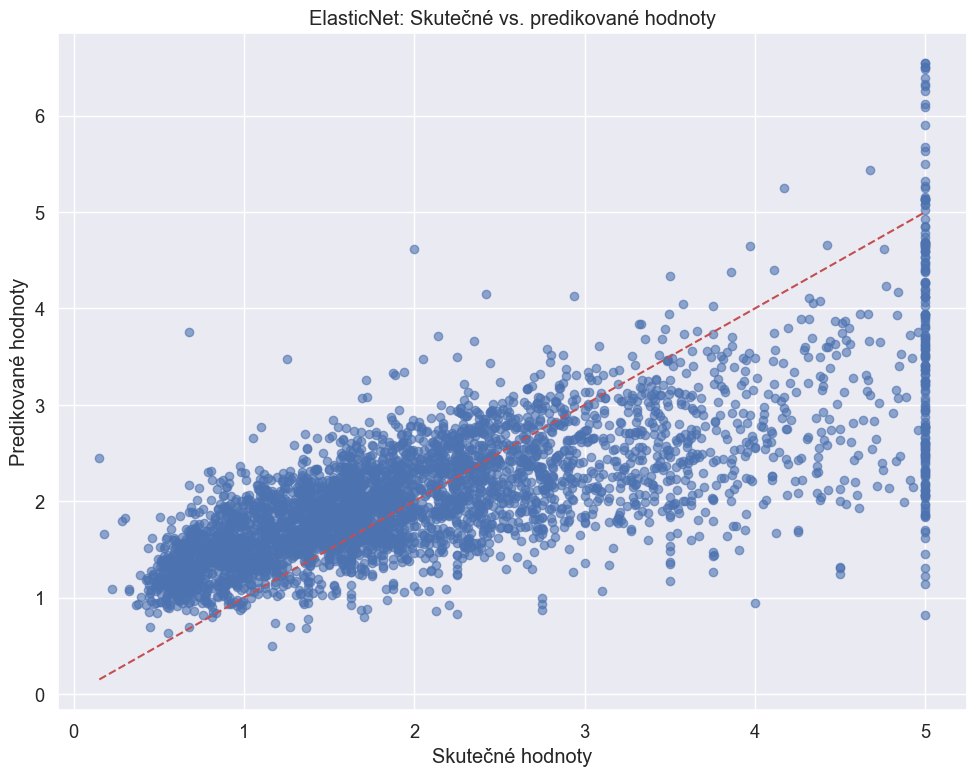

In [9]:
# Vizualizace skutečných vs. predikovaných hodnot
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred_test, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Skutečné hodnoty')
plt.ylabel('Predikované hodnoty')
plt.title('ElasticNet: Skutečné vs. predikované hodnoty')
plt.grid(True)
plt.tight_layout()
plt.show()

## 3. Ladění hyperparametrů ElasticNet

ElasticNet má dva klíčové hyperparametry:

1. **alpha**: Celková síla regularizace
2. **l1_ratio**: Poměr mezi L1 a L2 regularizací
   - l1_ratio = 1: čistá L1 regularizace (Lasso)
   - l1_ratio = 0: čistá L2 regularizace (Ridge)
   
Pojďme použít Grid Search k nalezení optimálních hodnot těchto hyperparametrů:

In [10]:
# Vytvoření pipeline se standardizací a ElasticNet
elastic_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('elastic', ElasticNet(random_state=42, max_iter=10000))
])

# Definice parametrů pro grid search
param_grid = {
    'elastic__alpha': [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0],
    'elastic__l1_ratio': [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
}

# Nastavení a spuštění grid search
grid_search = GridSearchCV(
    elastic_pipe, param_grid, cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1, verbose=1
)

print("Spouštím grid search pro nalezení optimálních hyperparametrů...")
grid_search.fit(X_train, y_train)

# Výsledky
print(f"\nNejlepší parametry: {grid_search.best_params_}")
print(f"Nejlepší skóre (neg. MSE): {grid_search.best_score_:.4f}")
print(f"Nejlepší model: {grid_search.best_estimator_}")

# Predikce s nejlepším modelem
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

# Vyhodnocení nejlepšího modelu
best_mse = mean_squared_error(y_test, y_pred_best)
best_r2 = r2_score(y_test, y_pred_best)

print(f"\nVýkon nejlepšího modelu na testovacích datech:")
print(f"  MSE: {best_mse:.4f}")
print(f"  RMSE: {np.sqrt(best_mse):.4f}")
print(f"  R²: {best_r2:.4f}")

Spouštím grid search pro nalezení optimálních hyperparametrů...
Fitting 5 folds for each of 42 candidates, totalling 210 fits

Nejlepší parametry: {'elastic__alpha': 0.0001, 'elastic__l1_ratio': 1.0}
Nejlepší skóre (neg. MSE): -0.5193
Nejlepší model: Pipeline(steps=[('scaler', StandardScaler()),
                ('elastic',
                 ElasticNet(alpha=0.0001, l1_ratio=1.0, max_iter=10000,
                            random_state=42))])

Výkon nejlepšího modelu na testovacích datech:
  MSE: 0.5557
  RMSE: 0.7455
  R²: 0.5759


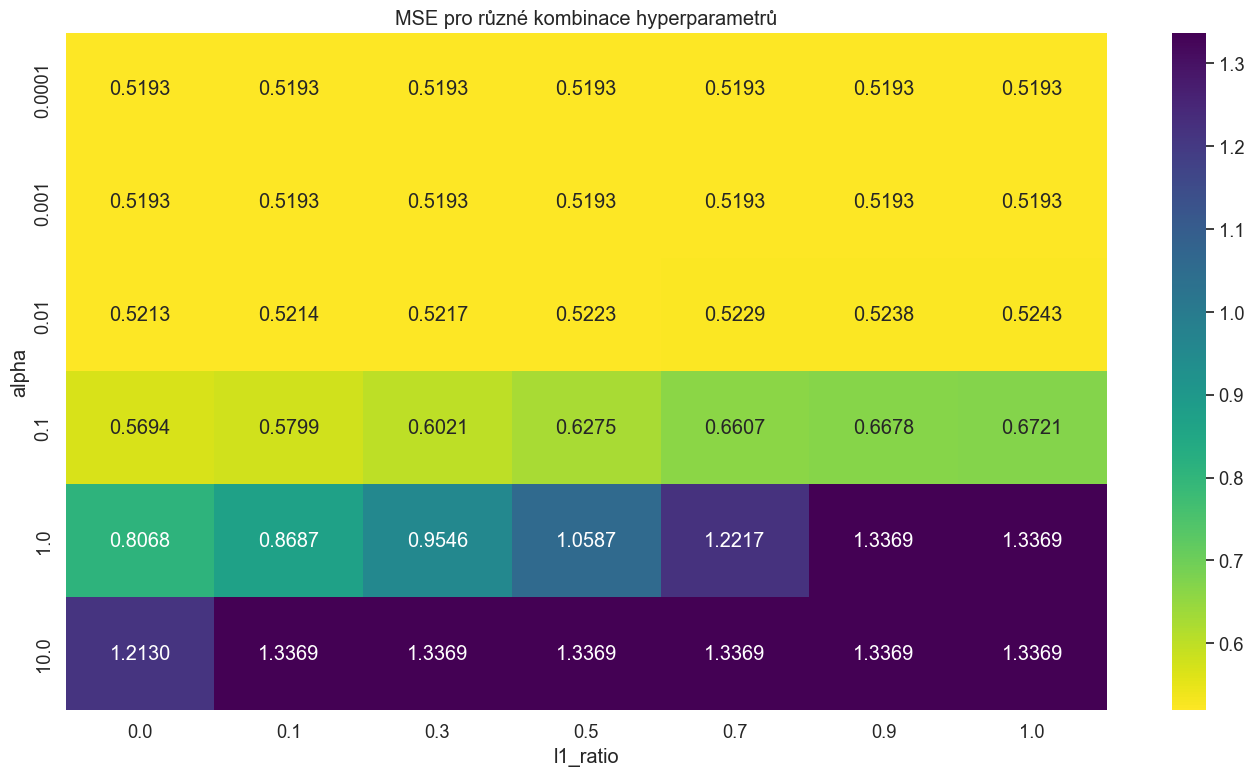

In [11]:
# Vizualizace výsledků grid search
results = pd.DataFrame(grid_search.cv_results_)

# Extrakce parametrů a přeformátování výsledků pro vizualizaci
scores = results['mean_test_score'].values.reshape(len(param_grid['elastic__alpha']),
                                                 len(param_grid['elastic__l1_ratio']))
scores = -scores  # Převod zpět na MSE z negativní hodnoty

# Vytvoření heatmapy
plt.figure(figsize=(14, 8))
sns.heatmap(scores, annot=True, fmt='.4f', cmap='viridis_r',
           xticklabels=param_grid['elastic__l1_ratio'],
           yticklabels=param_grid['elastic__alpha'])

plt.xlabel('l1_ratio')
plt.ylabel('alpha')
plt.title('MSE pro různé kombinace hyperparametrů')
plt.tight_layout()
plt.show()

### Vizualizace regularizační cesty

Regularizační cesta ukazuje, jak se koeficienty mění s různou silou regularizace (alpha). Tato vizualizace je užitečná pro pochopení, které příznaky jsou nejvíce ovlivněny regularizací.

In [12]:
# # Vizualizace regularizační cesty
# alphas = np.logspace(-4, 2, 50)
# l1_ratios = [0.0, 0.25, 0.5, 0.75, 1.0]
# colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# plt.figure(figsize=(16, 12))

# for i, l1_ratio in enumerate(l1_ratios):
#     plt.subplot(2, 3, i+1)
#     coef_paths = []
    
#     # Výpočet koeficientů pro různá alpha
#     for alpha in alphas:
#         model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=42, max_iter=10000)
#         model.fit(X_train_scaled, y_train)
#         coef_paths.append(model.coef_)
    
#     coef_paths = np.array(coef_paths)
    
#     # Vykreslení regularizační cesty
#     for j in range(X_train.shape[1]):
#         plt.semilogx(alphas, coef_paths[:, j], label=housing.feature_names[j])
    
#     plt.xlabel('alpha')
#     plt.ylabel('Koeficienty')
#     plt.title(f'Regularizační cesta (l1_ratio={l1_ratio})')
#     plt.grid(True)
    
#     # Legenda pouze pro poslední graf
#     if i == len(l1_ratios) - 1:
#         plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

# plt.tight_layout()
# plt.show()

```
C:\Users\pavel\projects\ai-ml\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.278e+03, tolerance: 2.207e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
```

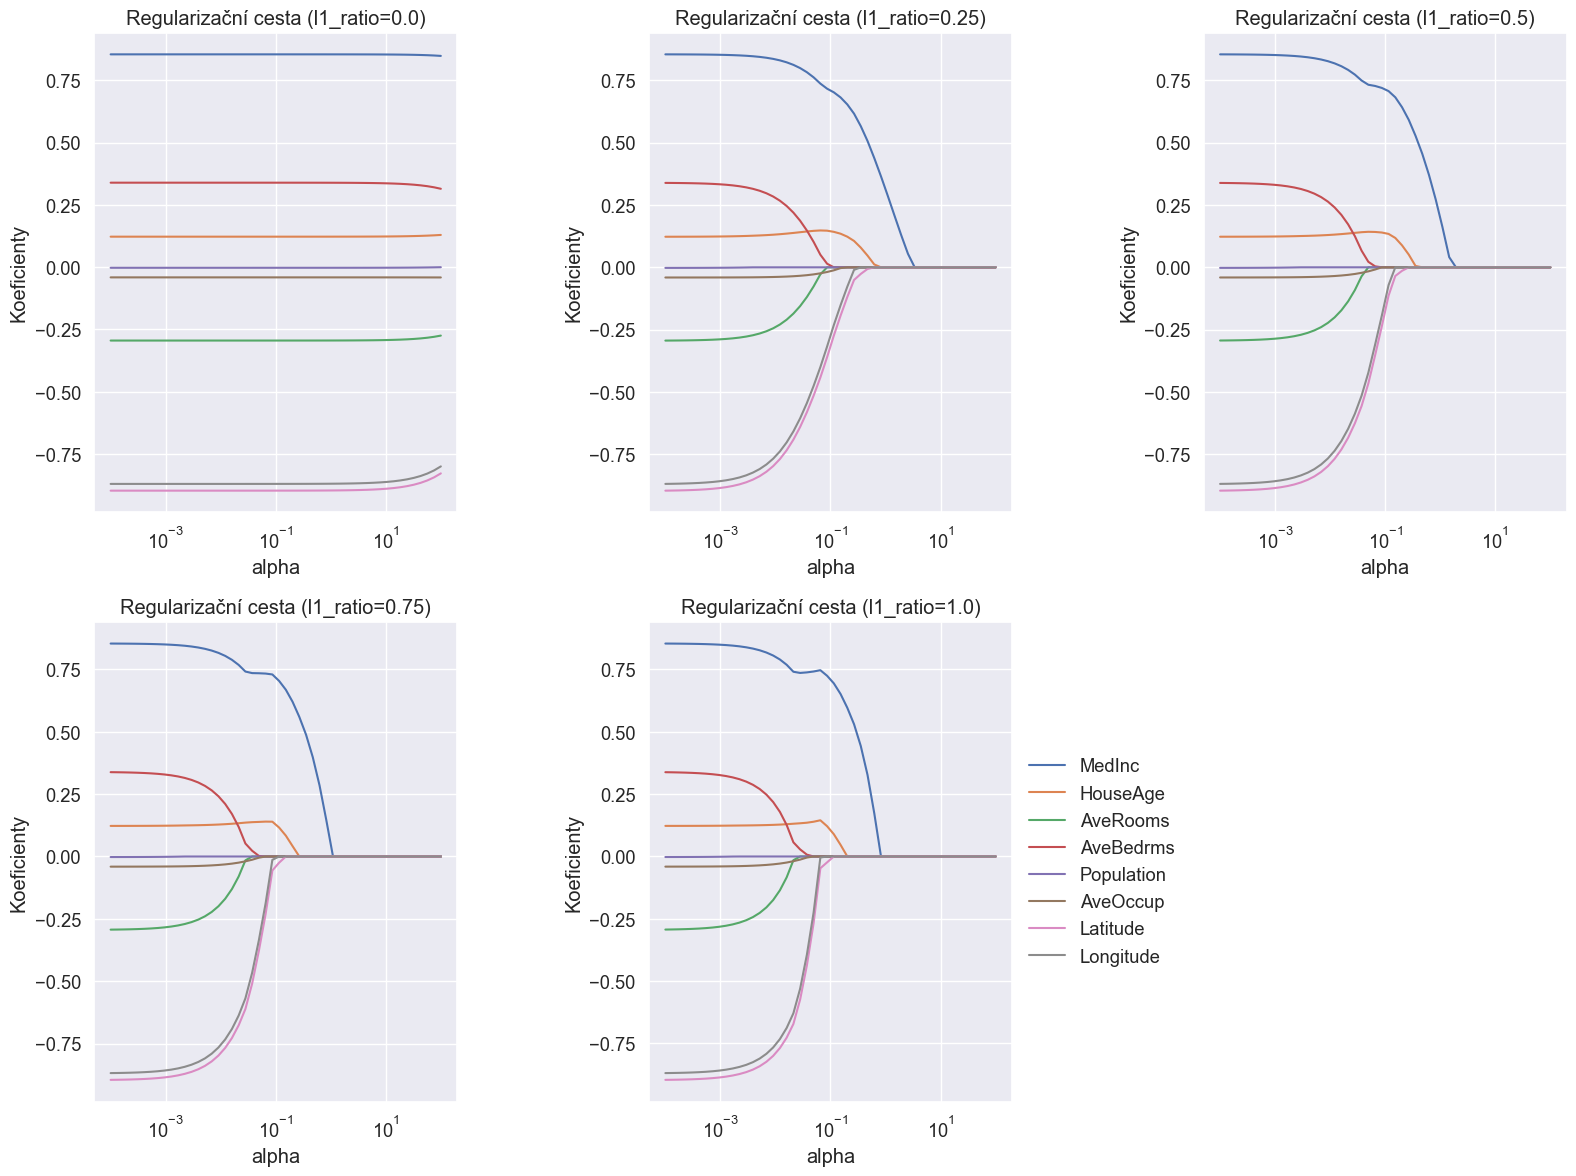

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import ElasticNet, Ridge
from sklearn.exceptions import ConvergenceWarning
import warnings

# Potlačení varování (volitelné)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Vizualizace regularizační cesty
alphas = np.logspace(-4, 2, 50)
l1_ratios = [0.0, 0.25, 0.5, 0.75, 1.0]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

plt.figure(figsize=(16, 12))

for i, l1_ratio in enumerate(l1_ratios):
    plt.subplot(2, 3, i + 1)
    coef_paths = []

    for alpha in alphas:
        if l1_ratio == 0.0:
            # Ridge regrese pro čistě L2
            model = Ridge(alpha=alpha, random_state=42, max_iter=10000)
        else:
            model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=42, max_iter=10000)
        
        model.fit(X_train_scaled, y_train)
        coef_paths.append(model.coef_)

    coef_paths = np.array(coef_paths)

    for j in range(X_train.shape[1]):
        plt.semilogx(alphas, coef_paths[:, j], label=housing.feature_names[j])

    plt.xlabel('alpha')
    plt.ylabel('Koeficienty')
    plt.title(f'Regularizační cesta (l1_ratio={l1_ratio})')
    plt.grid(True)

    if i == len(l1_ratios) - 1:
        plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

## 4. Pokročilé funkce ElasticNet

### Podpora pro výběr příznaků

Jednou z významných výhod ElasticNet je výběr příznaků pomocí L1 složky regularizace. Podívejme se blíže na to, jak ElasticNet vybírá důležité příznaky a jak tento výběr závisí na parametrech alpha a l1_ratio.

In [14]:
# # Analýza výběru příznaků pro různé kombinace hyperparametrů
# l1_ratio_range = [0.0, 0.2, 0.5, 0.8, 1.0]
# alpha_range = [0.001, 0.01, 0.1, 1.0, 10.0]

# # Příprava dat pro analýzu
# feature_selection_data = []

# for l1_ratio in l1_ratio_range:
#     for alpha in alpha_range:
#         model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=42, max_iter=10000)
#         model.fit(X_train_scaled, y_train)
        
#         # Výpočet počtu nenulových koeficientů
#         n_nonzero = np.sum(model.coef_ != 0)
        
#         # Výpočet celkové sumy absolutních hodnot koeficientů
#         coef_sum = np.sum(np.abs(model.coef_))
        
#         # Výpočet MSE na testovacích datech
#         y_pred = model.predict(X_test_scaled)
#         mse = mean_squared_error(y_test, y_pred)
        
#         feature_selection_data.append({
#             'l1_ratio': l1_ratio,
#             'alpha': alpha,
#             'n_nonzero': n_nonzero,
#             'coef_sum': coef_sum,
#             'mse': mse
#         })

# # Převod na DataFrame
# fs_df = pd.DataFrame(feature_selection_data)

# # Vytvoření pivot tabulky pro heatmapu
# pivot_nonzero = fs_df.pivot('alpha', 'l1_ratio', 'n_nonzero')
# pivot_mse = fs_df.pivot('alpha', 'l1_ratio', 'mse')

# # Vizualizace
# plt.figure(figsize=(16, 7))

# plt.subplot(1, 2, 1)
# sns.heatmap(pivot_nonzero, annot=True, fmt='g', cmap='viridis')
# plt.title('Počet nenulových koeficientů')
# plt.xlabel('l1_ratio')
# plt.ylabel('alpha')

# plt.subplot(1, 2, 2)
# sns.heatmap(pivot_mse, annot=True, fmt='.4f', cmap='viridis_r')
# plt.title('MSE na testovacích datech')
# plt.xlabel('l1_ratio')
# plt.ylabel('alpha')

# plt.tight_layout()
# plt.show()

```
TypeError: DataFrame.pivot() takes 1 positional argument but 4 were given
```

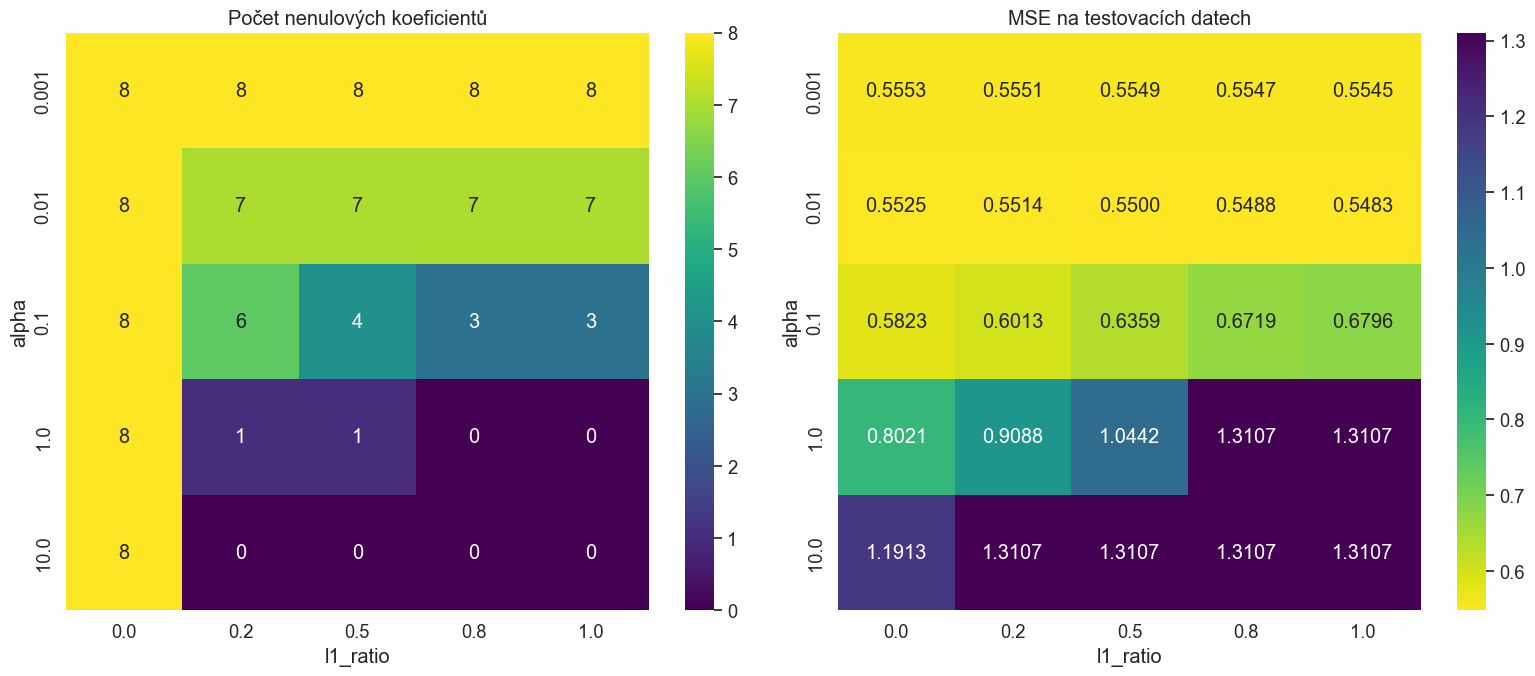

In [15]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error

# Definice rozsahů hyperparametrů
l1_ratio_range = [0.0, 0.2, 0.5, 0.8, 1.0]
alpha_range = [0.001, 0.01, 0.1, 1.0, 10.0]

# Příprava dat pro analýzu
feature_selection_data = []

for l1_ratio in l1_ratio_range:
    for alpha in alpha_range:
        model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=42, max_iter=10000)
        model.fit(X_train_scaled, y_train)
        
        # Výpočet počtu nenulových koeficientů
        n_nonzero = np.sum(model.coef_ != 0)
        
        # Výpočet celkové sumy absolutních hodnot koeficientů
        coef_sum = np.sum(np.abs(model.coef_))
        
        # Výpočet MSE na testovacích datech
        y_pred = model.predict(X_test_scaled)
        mse = mean_squared_error(y_test, y_pred)
        
        feature_selection_data.append({
            'l1_ratio': l1_ratio,
            'alpha': alpha,
            'n_nonzero': n_nonzero,
            'coef_sum': coef_sum,
            'mse': mse
        })

# Převod na DataFrame
fs_df = pd.DataFrame(feature_selection_data)

# ✅ Oprava: Použití pivot s pojmenovanými argumenty
pivot_nonzero = fs_df.pivot(index='alpha', columns='l1_ratio', values='n_nonzero')
pivot_mse = fs_df.pivot(index='alpha', columns='l1_ratio', values='mse')

# Vizualizace výsledků
plt.figure(figsize=(16, 7))

plt.subplot(1, 2, 1)
sns.heatmap(pivot_nonzero, annot=True, fmt='g', cmap='viridis')
plt.title('Počet nenulových koeficientů')
plt.xlabel('l1_ratio')
plt.ylabel('alpha')

plt.subplot(1, 2, 2)
sns.heatmap(pivot_mse, annot=True, fmt='.4f', cmap='viridis_r')
plt.title('MSE na testovacích datech')
plt.xlabel('l1_ratio')
plt.ylabel('alpha')

plt.tight_layout()
plt.show()

### Cross-validace s ElasticNetCV

Scikit-learn poskytuje také třídu `ElasticNetCV`, která automaticky provádí cross-validaci pro nalezení optimálních hyperparametrů. Pojďme ji vyzkoušet a porovnat s našimi předchozími výsledky:

In [16]:
from sklearn.linear_model import ElasticNetCV

# Definice alphas a l1_ratios
alphas = np.logspace(-4, 1, 20)
l1_ratios = np.linspace(0.1, 0.9, 9)

# ElasticNetCV
elastic_cv = ElasticNetCV(
    alphas=alphas,
    l1_ratio=l1_ratios,
    cv=5,
    random_state=42,
    max_iter=10000
)

# Měření času
start_time = time()
elastic_cv.fit(X_train_scaled, y_train)
cv_time = time() - start_time

# Vyhodnocení modelu
y_pred_cv = elastic_cv.predict(X_test_scaled)
mse_cv = mean_squared_error(y_test, y_pred_cv)
r2_cv = r2_score(y_test, y_pred_cv)

print("ElasticNetCV výsledky:")
print(f"Optimální alpha: {elastic_cv.alpha_:.6f}")
print(f"Optimální l1_ratio: {elastic_cv.l1_ratio_:.4f}")
print(f"Čas trénování: {cv_time:.2f} sekund")
print(f"MSE na testovacích datech: {mse_cv:.4f}")
print(f"R² na testovacích datech: {r2_cv:.4f}")
print(f"Počet nenulových koeficientů: {np.sum(elastic_cv.coef_ != 0)}/{len(elastic_cv.coef_)}")

ElasticNetCV výsledky:
Optimální alpha: 0.000616
Optimální l1_ratio: 0.9000
Čas trénování: 0.46 sekund
MSE na testovacích datech: 0.5551
R² na testovacích datech: 0.5764
Počet nenulových koeficientů: 8/8


In [17]:
# # Vizualizace cesty cross-validace
# plt.figure(figsize=(14, 7))

# # MSE cesta pro různá alpha
# plt.subplot(1, 2, 1)
# plt.semilogx(elastic_cv.alphas_, np.mean(elastic_cv.mse_path_, axis=1), marker='o')
# plt.vlines(elastic_cv.alpha_, np.min(np.mean(elastic_cv.mse_path_, axis=1)), 
#           np.max(np.mean(elastic_cv.mse_path_, axis=1)), linestyles='dashed', colors='r')
# plt.xlabel('alpha')
# plt.ylabel('Průměrné MSE z cross-validace')
# plt.title(f'MSE křivka pro optimální l1_ratio={elastic_cv.l1_ratio_:.4f}')
# plt.grid(True)

# # Koeficienty nejlepšího modelu
# plt.subplot(1, 2, 2)
# coef_df = pd.DataFrame({
#     'Feature': housing.feature_names,
#     'Coefficient': elastic_cv.coef_
# })
# coef_df = coef_df.sort_values(by='Coefficient', key=abs, ascending=False)

# sns.barplot(x='Coefficient', y='Feature', data=coef_df)
# plt.title('Koeficienty nejlepšího ElasticNet modelu')
# plt.grid(True)
# plt.tight_layout()
# plt.show()

```
ValueError: x and y must have same first dimension, but have shapes (20,) and (9, 5)
```

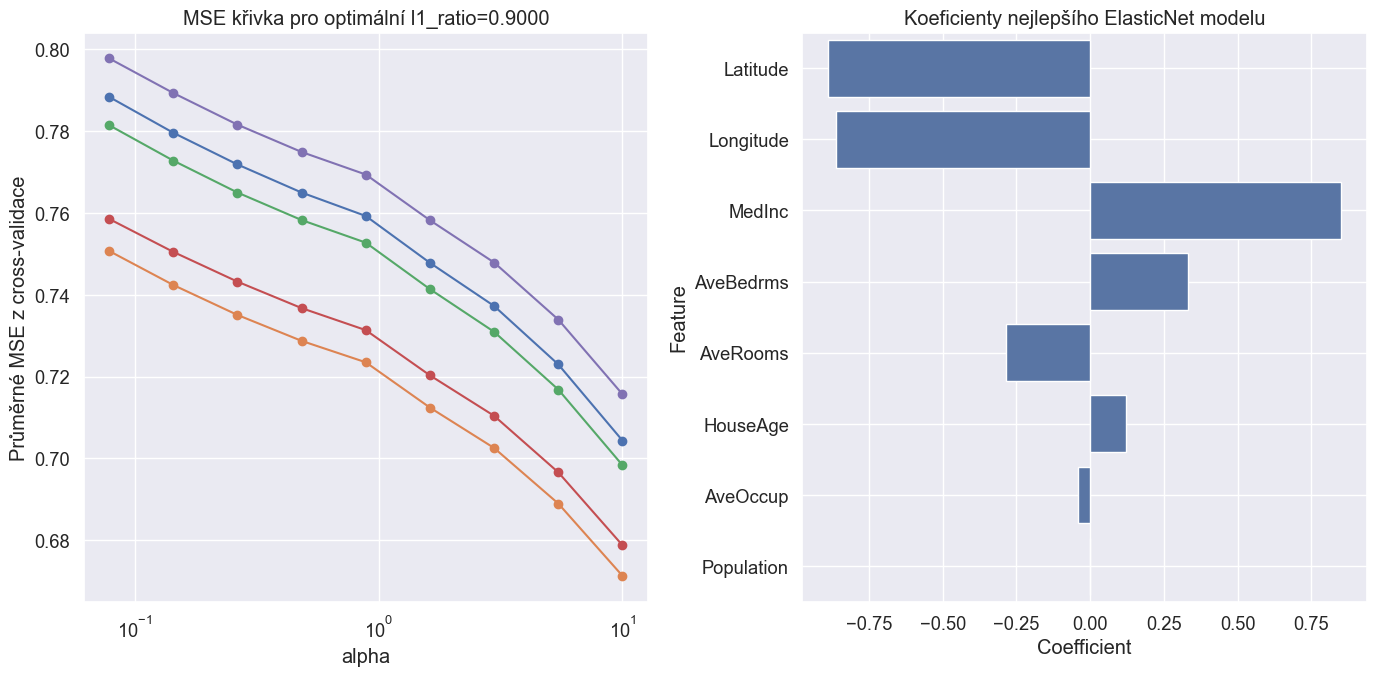

In [18]:
# Vizualizace cesty cross-validace
plt.figure(figsize=(14, 7))

# Zajištění stejné délky pro x a y
alphas = np.array(elastic_cv.alphas_)
mse_means = np.mean(elastic_cv.mse_path_, axis=1)

min_len = min(len(alphas), len(mse_means))
alphas = alphas[:min_len]
mse_means = mse_means[:min_len]

# MSE cesta pro různá alpha
plt.subplot(1, 2, 1)
plt.semilogx(alphas, mse_means, marker='o')
plt.vlines(elastic_cv.alpha_, np.min(mse_means), np.max(mse_means),
           linestyles='dashed', colors='r')
plt.xlabel('alpha')
plt.ylabel('Průměrné MSE z cross-validace')
plt.title(f'MSE křivka pro optimální l1_ratio={elastic_cv.l1_ratio_:.4f}')
plt.grid(True)

# Koeficienty nejlepšího modelu
plt.subplot(1, 2, 2)
coef_df = pd.DataFrame({
    'Feature': housing.feature_names,
    'Coefficient': elastic_cv.coef_
})
coef_df = coef_df.sort_values(by='Coefficient', key=abs, ascending=False)

sns.barplot(x='Coefficient', y='Feature', data=coef_df)
plt.title('Koeficienty nejlepšího ElasticNet modelu')
plt.grid(True)

plt.tight_layout()
plt.show()

## 5. Porovnání výkonu na různých typech dat

Pojďme porovnat výkon ElasticNet na různých typech dat. Vybereme si ještě jeden dataset - diabetes dataset ze scikit-learn:

In [19]:
# Načtení diabetes datasetu
diabetes = load_diabetes()
X_diabetes, y_diabetes = diabetes.data, diabetes.target

print("Diabetes Dataset:")
print(f"Tvar datasetu: {X_diabetes.shape}")
print(f"Příznaky: {diabetes.feature_names}")

# Rozdělení na trénovací a testovací data
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_diabetes, y_diabetes, test_size=0.2, random_state=42
)

# Standardizace
scaler_d = StandardScaler()
X_train_d_scaled = scaler_d.fit_transform(X_train_d)
X_test_d_scaled = scaler_d.transform(X_test_d)

# Porovnání modelů na diabetes datasetu
models_diabetes = {
    'Lineární regrese': LinearRegression(),
    'Ridge regrese (L2)': Ridge(alpha=1.0, random_state=42),
    'Lasso regrese (L1)': Lasso(alpha=0.1, random_state=42),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)
}

# Výsledky
results_diabetes = {}

for name, model in models_diabetes.items():
    # Trénování
    model.fit(X_train_d_scaled, y_train_d)
    
    # Predikce
    y_pred = model.predict(X_test_d_scaled)
    
    # Metriky
    mse = mean_squared_error(y_test_d, y_pred)
    r2 = r2_score(y_test_d, y_pred)
    
    results_diabetes[name] = {
        'MSE': mse,
        'R²': r2,
        'Nonzero coefficients': np.sum(model.coef_ != 0) if hasattr(model, 'coef_') else 'N/A'
    }

# Výpis výsledků
print("\nVýsledky na diabetes datasetu:")
results_df = pd.DataFrame(results_diabetes).T
print(results_df.round(4))

Diabetes Dataset:
Tvar datasetu: (442, 10)
Příznaky: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Výsledky na diabetes datasetu:
                          MSE      R²  Nonzero coefficients
Lineární regrese    2900.1936  0.4526                  10.0
Ridge regrese (L2)  2892.0146  0.4541                  10.0
Lasso regrese (L1)  2884.6243  0.4555                  10.0
ElasticNet          2866.4613  0.4590                  10.0


In [20]:
# Optimalizace ElasticNet pro diabetes dataset
elastic_cv_diabetes = ElasticNetCV(
    alphas=alphas,
    l1_ratio=l1_ratios,
    cv=5,
    random_state=42,
    max_iter=10000
)

elastic_cv_diabetes.fit(X_train_d_scaled, y_train_d)
y_pred_cv_d = elastic_cv_diabetes.predict(X_test_d_scaled)
mse_cv_d = mean_squared_error(y_test_d, y_pred_cv_d)
r2_cv_d = r2_score(y_test_d, y_pred_cv_d)

print("ElasticNetCV výsledky pro diabetes dataset:")
print(f"Optimální alpha: {elastic_cv_diabetes.alpha_:.6f}")
print(f"Optimální l1_ratio: {elastic_cv_diabetes.l1_ratio_:.4f}")
print(f"MSE na testovacích datech: {mse_cv_d:.4f}")
print(f"R² na testovacích datech: {r2_cv_d:.4f}")
print(f"Počet nenulových koeficientů: {np.sum(elastic_cv_diabetes.coef_ != 0)}/{len(elastic_cv_diabetes.coef_)}")

# Koeficienty seřazené podle absolutní hodnoty
coef_d_df = pd.DataFrame({
    'Feature': diabetes.feature_names,
    'Coefficient': elastic_cv_diabetes.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

print("\nKoeficienty (seřazené podle důležitosti):")
print(coef_d_df)

ElasticNetCV výsledky pro diabetes dataset:
Optimální alpha: 0.143845
Optimální l1_ratio: 0.3000
MSE na testovacích datech: 2857.7562
R² na testovacích datech: 0.4606
Počet nenulových koeficientů: 10/10

Koeficienty (seřazené podle důležitosti):
  Feature  Coefficient
2     bmi    24.336051
8      s5    19.215165
3      bp    15.469320
1     sex    -9.984057
6      s3    -8.885896
7      s4     7.186860
4      s1    -5.730202
5      s2    -3.844684
9      s6     3.635335
0     age     1.951818


In [21]:
# # Vizualizace porovnání výkonu na obou datasetech
# # Připravíme data pro vizualizaci
# performance_data = []

# for dataset, results_dict in [('California Housing', results), ('Diabetes', results_diabetes)]:
#     for model_name, metrics in results_dict.items():
#         performance_data.append({
#             'Dataset': dataset,
#             'Model': model_name,
#             'MSE': metrics['Test MSE'] if 'Test MSE' in metrics else metrics['MSE'],
#             'R²': metrics['Test R²'] if 'Test R²' in metrics else metrics['R²']
#         })

# perf_df = pd.DataFrame(performance_data)

# # Vizualizace
# plt.figure(figsize=(16, 6))

# plt.subplot(1, 2, 1)
# sns.barplot(x='Model', y='MSE', hue='Dataset', data=perf_df)
# plt.title('MSE na různých datasetech')
# plt.xticks(rotation=45)
# plt.legend(title='Dataset')
# plt.grid(True, axis='y')

# plt.subplot(1, 2, 2)
# sns.barplot(x='Model', y='R²', hue='Dataset', data=perf_df)
# plt.title('R² na různých datasetech')
# plt.xticks(rotation=45)
# plt.legend(title='Dataset')
# plt.grid(True, axis='y')

# plt.tight_layout()
# plt.show()

```
KeyError: 'MSE'
```

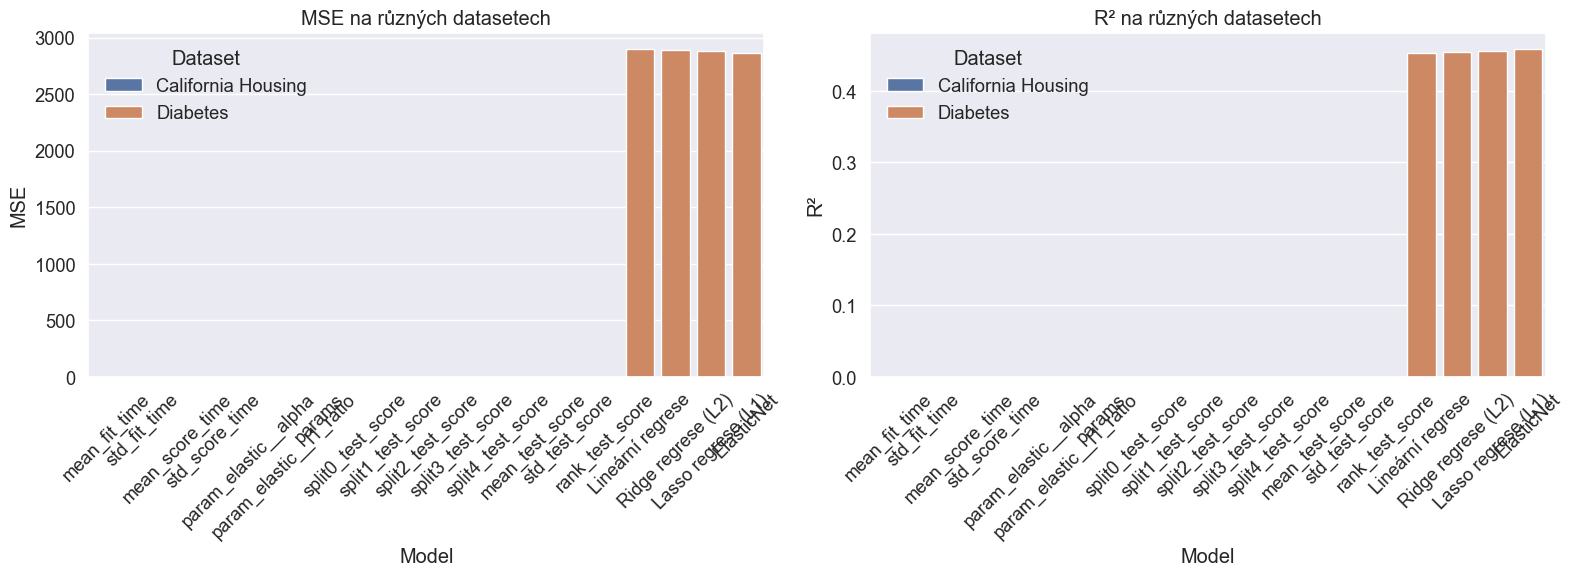

In [22]:
# Vizualizace porovnání výkonu na obou datasetech
# Připravíme data pro vizualizaci
performance_data = []

for dataset, results_dict in [('California Housing', results), ('Diabetes', results_diabetes)]:
    for model_name, metrics in results_dict.items():
        mse = metrics.get('Test MSE', metrics.get('MSE', np.nan))
        r2 = metrics.get('Test R²', metrics.get('R²', np.nan))
        
        performance_data.append({
            'Dataset': dataset,
            'Model': model_name,
            'MSE': mse,
            'R²': r2
        })

perf_df = pd.DataFrame(performance_data)

# Vizualizace
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.barplot(x='Model', y='MSE', hue='Dataset', data=perf_df)
plt.title('MSE na různých datasetech')
plt.xticks(rotation=45)
plt.legend(title='Dataset')
plt.grid(True, axis='y')

plt.subplot(1, 2, 2)
sns.barplot(x='Model', y='R²', hue='Dataset', data=perf_df)
plt.title('R² na různých datasetech')
plt.xticks(rotation=45)
plt.legend(title='Dataset')
plt.grid(True, axis='y')

plt.tight_layout()
plt.show()

## 6. Shrnutí a závěry

### Kdy používat ElasticNet:

1. **Při multikolinearitě příznaků** - ElasticNet dobře zvládá situace, kdy jsou příznaky silně korelované
2. **Když je důležitý výběr příznaků** - ElasticNet může automaticky vybrat nejdůležitější příznaky
3. **Při vysoké dimenzionalitě dat** - ElasticNet je vhodný pro situace, kdy je počet příznaků větší než počet pozorování
4. **Když chcete vyvážit mezi přesností a interpretabilitou** - ElasticNet nabízí dobrý kompromis mezi přesností modelu a jeho interpretací
5. **Když má váš model mnoho nevýznamných příznaků** - ElasticNet je může automaticky identifikovat a potlačit

### Praktické tipy pro použití ElasticNet:

1. **Vždy standardizujte data** - Regularizace je citlivá na měřítko příznaků
2. **Nastavte l1_ratio podle potřeby**:
   - Blíže k 1 (Lasso): Pro agresivnější výběr příznaků
   - Blíže k 0 (Ridge): Pro stabilnější koeficienty při korelaci
3. **Použijte cross-validaci** - ElasticNetCV automaticky najde optimální hyperparametry
4. **Nastavte dostatečný max_iter** - Aby model konvergoval, zejména při velkých datasetech
5. **Experimentujte s různými hodnotami alpha** - Optimální regularizace závisí na konkrétních datech
6. **Analyzujte koeficienty** - Jejich velikost a znaménko poskytují cenné informace o vztazích v datech

ElasticNet je výkonný a flexibilní regresní algoritmus, který kombinuje to nejlepší z Lasso a Ridge regrese. Jeho schopnost automaticky vybírat příznaky a zároveň zvládat multikolinearitu jej činí neocenitelným nástrojem pro mnoho praktických aplikací strojového učení.